## Normalization

Normalizaiton is a technique often applied as part of data preparation for machine learning . The goal of normalization is to change the values of numeric columns in the dataset to use a common scale , without distorting difference in the ranges of values or losing information.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df=pd.read_csv("dataset/wine.csv",header=0, usecols=[1,2,3])
df.columns=["Class label","Alcohol","Malic acid"]

In [50]:
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [51]:
df.describe()

,Class label,Alcohol,Malic acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


<Axes: xlabel='Alcohol', ylabel='Density'>

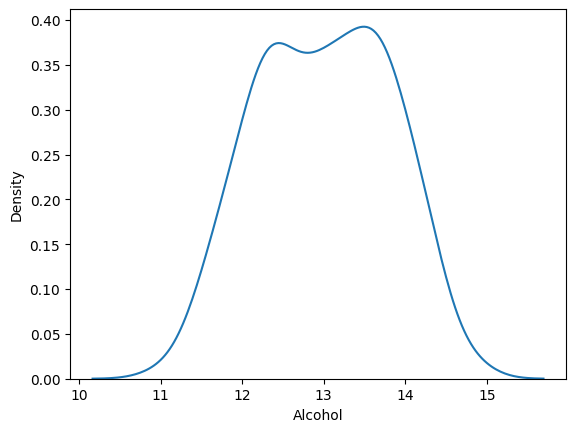

In [52]:
sns.kdeplot(data=df,x="Alcohol") #pdf

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

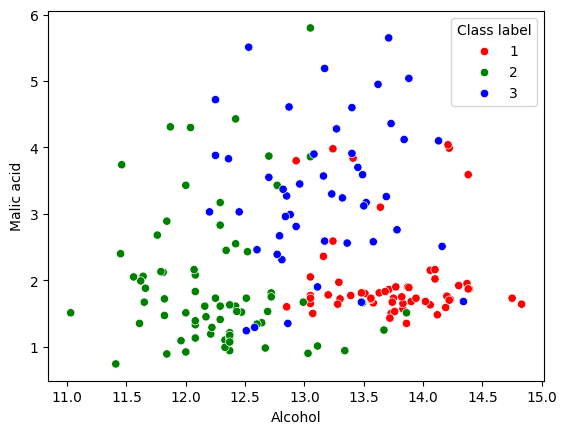

In [53]:
sns.scatterplot(data=df,x="Alcohol",y="Malic acid",hue="Class label",palette=["red","green","blue"])

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop("Class label",axis=1),df["Class label"],test_size=0.3,random_state=0)

In [55]:
X_train.shape,X_test.shape,y_train.shape

((124, 2), (54, 2), (124,))

In [56]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [57]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [58]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


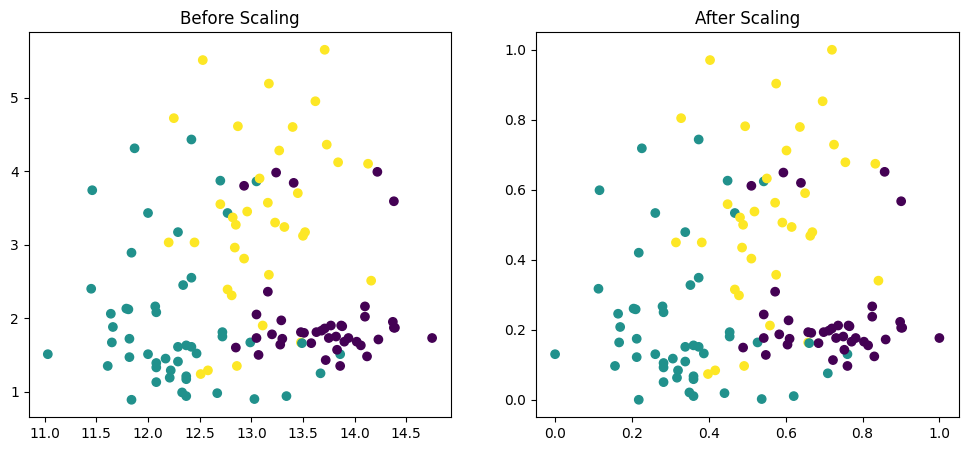

In [59]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train["Alcohol"],X_train["Malic acid"],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled["Alcohol"],X_train_scaled["Malic acid"],c=y_train)
ax2.set_title("After Scaling")
plt.show()


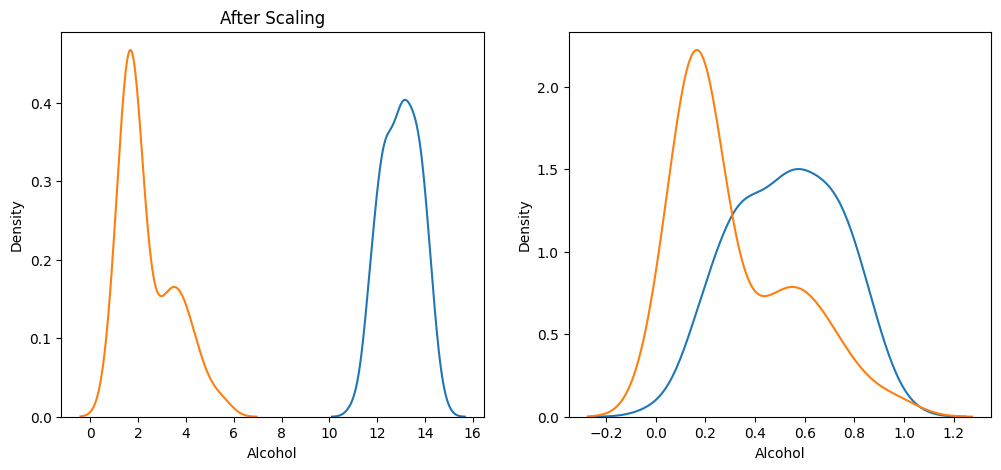

In [60]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Alcohol"],ax=ax1)
sns.kdeplot(X_train["Malic acid"],ax=ax1)


# after scaling
ax1.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Alcohol"],ax=ax2)
sns.kdeplot(X_train_scaled["Malic acid"],ax=ax2)
plt.show()

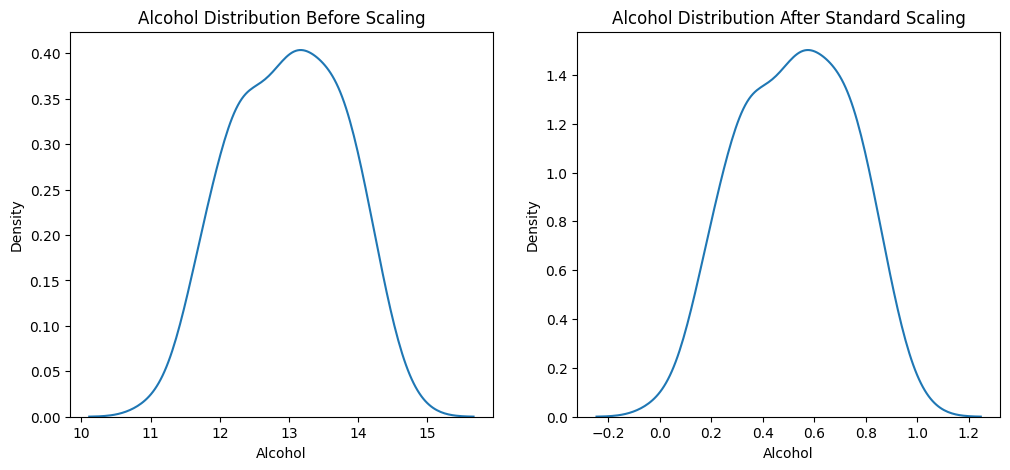

In [61]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Alcohol Distribution Before Scaling")
sns.kdeplot(X_train["Alcohol"],ax=ax1)



# after scaling
ax2.set_title("Alcohol Distribution After Standard Scaling")
sns.kdeplot(X_train_scaled["Alcohol"],ax=ax2)
plt.show()

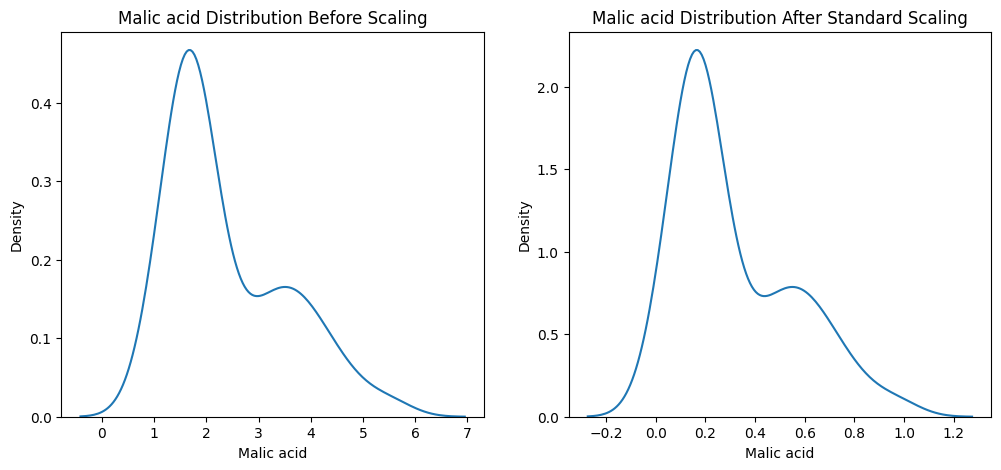

In [62]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Malic acid Distribution Before Scaling")
sns.kdeplot(X_train["Malic acid"],ax=ax1)



# after scaling
ax2.set_title("Malic acid Distribution After Standard Scaling")
sns.kdeplot(X_train_scaled["Malic acid"],ax=ax2)
plt.show()